### 1. Dependencies

In [452]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe,get_japan_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_famafrench_factors, get_processed_index, get_accounting_data
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe, process_japan_universe

In [453]:
#Important Filters
#############################################################

golden_data = "v_2B1"

region_analysis = "Japan"

#esg only till 2022
esg_choice = "none" # "refinitiv_n_s&p" # "refinitiv_n_s&p"#"s&p"#"s&p"#"none"#""refinitiv_n_s&p" #refinitiv"

#Univariate Sorting Percentile Split number
no_simple_quantiles = 5


add_accounting_data = True

show_sector_portfolio =  False

start_year = 2014                 # these ESG sources are aligned for `start_year==2013`
end_year = 2022

#sector split
top_x_by_industry_even_split = 6

#Filtering the GOLDEN data equally top and bottom
use_alpha_bound = True

##############################


# Other Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

#Other Initalising variables
drop_real_estate = True
fama_factor_region = "Developed"
currency_filter=None
convert_to_USD = True


if region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    

if region_analysis == "Europe_and_North_America_and_Japan":
    #currencies we keep
    currency_filter = ['EUR', 'USD', 'JPY'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    #check JPY currency conversion (Might need to invert it)
    
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    


elif region_analysis == "North_America":
    currency_filter = ['USD'] 
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    fama_factor_region = "North_America"
    convert_to_USD = False
    

elif region_analysis == "Europe":
    currency_filter = ['EUR'] #"None" for uk
    region_filter = ["Europe"]
    execute_region_filters = True 
    #Keep in local currency
    #If we dont filter by EUR
    convert_to_USD = False    #True if UK
    fama_factor_region = "Europe"
  

elif region_analysis == "Japan":
    currency_filter = ['JPY'] 
    region_filter = ["Asia-Pacific"]
    execute_region_filters = True 
    #Keep in local currency
    convert_to_USD = False
    fama_factor_region = "Japan"

In [454]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

# Golden Dataset



if golden_data == "v_2A":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
elif golden_data == "v_2B1":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")

# 1. Parameters 

In [455]:
# --- Parameter summary (prints below the cell) ---
param_names = [
    "region_analysis",
    "esg_choice",
    "no_simple_quantiles",
    "add_accounting_data",
    "show_sector_portfolio",
    "start_year",
    "end_year",
    "top_x_by_industry_even_split",
    "use_alpha_bound",
    "alpha_bound",
    "mktcap_covered",
    "drop_real_estate",
    "fama_factor_region",
    "currency_filter",
    "convert_to_USD",
    "golden_data",
]

print("\n=== Run parameters ===")
for k in param_names:
    v = locals().get(k, "<not set>")
    print(f"{k:28} = {v!r}")
print("======================\n")


=== Run parameters ===
region_analysis              = 'Japan'
esg_choice                   = 'none'
no_simple_quantiles          = 5
add_accounting_data          = True
show_sector_portfolio        = False
start_year                   = 2014
end_year                     = 2022
top_x_by_industry_even_split = 6
use_alpha_bound              = True
alpha_bound                  = 0.1
mktcap_covered               = 0.95
drop_real_estate             = True
fama_factor_region           = 'Japan'
currency_filter              = ['JPY']
convert_to_USD               = False
golden_data                  = 'v_2B1'



Signal Design

In [456]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo, test_multiple_signals

#Choose which action characterization to use, which is dependent on function

#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()
#categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = test_multiple_signals()


#What signals to include~~~
lc_signals = {
    "signal_0": signal_0_name,
    "signal_1": signal_1_name,
    "signal_2": signal_2_name,
   
}

Signal Choice

In [457]:

analyse_high_low = "High"
if esg_choice == "none":

    universe_signals = {}

    if analyse_high_low == "High":
        analysis_selection = [("signal_2", "high"), ("signal_1","high"), ("signal_0","high")]
    elif analyse_high_low == "Low":
        analysis_selection = [("signal_2", "low"), ("signal_1","low"), ("signal_0","low")]



elif esg_choice == "refinitiv":
    universe_signals = {"esg_refinitive": "esg_refinitive",}
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high")]
elif esg_choice == "s&p":
    universe_signals = {    "esg_sp": "esg_sp",}
    analysis_selection = [("esg_sp", "high"), ("esg_sp", "low"), ("signal_0", "high"), ("signal_1", "high"), ("signal_2", "high")]
elif esg_choice == "refinitiv_n_s&p":
    universe_signals = {    "esg_sp": "esg_sp",    "esg_refinitive": "esg_refinitive",}
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high"), ("esg_sp", "high")]

### 2. Data

Golden Data

#### 2.1 LC dataset

clean below

In [458]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)


if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']

#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]


In [459]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [460]:
# lc["sum_activities"].describe()

In [461]:
if use_alpha_bound:

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (alpha_bound/2),
        upper_exclude= (alpha_bound/2),
    )

else:
    lower_exclude = 0.2*2
    upper_exclude = 0.05*2

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (lower_exclude/2),
        upper_exclude= (upper_exclude/2),
    )

In [462]:
# lc["sum_activities"].describe()

Create the signal

In [463]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [464]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

0

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4 - Japan

5 - ESG

4- Fama-French

5- Global Universe

6- Accounting Data

In [465]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)

# Keep local-currency series for Europe/Japan analysis (no FX conversion)

usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year, end_year, download_wrds_data=False)
row_universe = process_row_universe(row_universe,fx_rates,convert_to_USD,)

japan_universe = get_japan_universe(start_year, end_year, download_wrds_data=False)
japan_universe = process_japan_universe(japan_universe,fx_rates,convert_to_USD,)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100
    japan_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == 'refinitiv_n_s&p':
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "refinitiv":
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)

fama_french = get_famafrench_factors(
    start_year,
    end_year,
    fama_factor_region,
    download_developed_ff_data=False,
)

global_universe = process_global_universe(usa_universe,row_universe,japan_universe,currency_filter,mktcap_covered,
    esg_choice,)

print("columns with year")
print([c for c in global_universe.columns if c == 'year' or c.startswith('year_')])

# if add_accounting_data:
#     #Note this will result in a lower sample and non-profitable stocks will be removed
#     global_universe = global_universe.drop(columns=['year_x'], errors='ignore')
#     global_universe = get_accounting_data(global_universe, region_analysis, start_year, end_year, dowload_acc_data = True)


#Ensure gvkey is 6 digits for merging
global_universe["gvkey"] = global_universe["gvkey"].astype(str).str.zfill(6)
lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)

columns with year
['year']


In [466]:
# global_universe["gvkey"].astype(str).str.len().value_counts()   

In [467]:
# lc["gvkey"].astype(str).str.len().value_counts()   

### 3. Univariate Portfolio sorting

In [468]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']



prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    lc_signals=lc_signals,
    universe_signals=universe_signals,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french




% Nan in accounting data

In [469]:
# if add_accounting_data:
#     #Amount of missing accounting data as a percent
#     cols = ["roa0","roa1","roa2","ros0","ros1","ros2","sales_intensity"]
#     print((100 * global_universe[cols].isna().mean()).sort_values(ascending=False))

In [470]:
global_universe.to_csv(f"./data/Global_Universe/{golden_data}_Global_Universe_{region_analysis}_{end_year}.csv")

In [471]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [472]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

In [473]:
# Store constituents over time + compute “next-month return” by Industry


from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio


if show_sector_portfolio:
    # Sector portfolio is pinned to signal_2.
    global_signal_2 = signals["signal_2"]

    #Build an industry pivot aligned to global_returns  and global_signal_*
    global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

    #This will automatically split the even_split_no stocks into the unique sectors.
    #Select the n highest ranked stocks in each industruy and build portfolios using them.
    S = SectorPortfolio(
        signal=global_signal_2,
        returns=global_returns,
        global_universe=global_universe,
        sector_split=top_x_by_industry_even_split,          # fixed N per industry
        manual_input_split=False,
        first_conditioning_set=first_conditioning_set,
        ascending=False,
    )


    #all_industry_returns = S.compute_industry_returns()
    industry_constituents = S.get_constituents_over_time()   

    #Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
    sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


In [474]:
# Add Market Portfolios
market_factor = fama_french["mktrf"]

file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

In [475]:
# Transform in excess returns using the risk free rate

for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

if show_sector_portfolio:
    sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)


Excess_returns_sample = (
    global_returns.mean(axis=1)
    .sub(fama_french["rf"].values, axis=0)
    .to_frame("Sample")
)

#no need for market_factor


In [476]:
# Make sure the first row is 0, so they all start at the same date

global_returns = set_first_row_to_zero(global_returns)
for col in signal_quantiles:
    signal_quantiles[col] = set_first_row_to_zero(signal_quantiles[col])
    
MSCI_excess_returns.iloc[0] = 0
market_factor.iloc[0] =0


if show_sector_portfolio:
    sector_portfolio_returns.iloc[0] = 0

# 5. Fama-French

In [477]:

if show_sector_portfolio:
    sector_portfolio_returns_df = pd.DataFrame()
    sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
    sector_portfolio_returns = sector_portfolio_returns_df

In [478]:
from functions.portfolio_metrics.fama_french import ff3_regressions, rolling_ff3_alphas

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]
if show_sector_portfolio:
    ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))
    
ff3_parts.append(ff3_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low advocacy,High advocacy,Low preparation,High preparation,Low transformation,High transformation,Sample
alpha,0.22,0.21,0.17,0.27,0.27,0.21,0.24
beta_mkt,1.09,0.92,0.94,1.08,0.96,1.00,0.99
beta_smb,0.02,0.20,0.14,0.09,0.20,0.09,0.11
beta_hml,0.34,0.30,0.33,0.38,0.38,0.35,0.37
p-value(alpha),0.51,0.51,0.60,0.41,0.38,0.48,0.43


In [479]:
#### Rolling Alpha


window_size = 24

base_analysis_selection = [("signal_2", "high"), ("signal_1", "high"), ("signal_0", "high")]

# if show_sector_portfolio:
#     base_analysis_selection.append(("Sector equal split signal_2", "high"))


#analyse_high_low = "Low"
#analyse_high_low = "High"

if esg_choice == "refinitiv":
    analysis_selection = [("esg_refinitive", "high"), ("signal_2", "high"), ("signal_1", "high")]
elif esg_choice == "s&p":
    analysis_selection = [("esg_sp", "high"), ("signal_2", "high"), ("signal_1", "high")]
elif esg_choice == "none":
    analysis_selection = base_analysis_selection
    

# if analyse_high_low == "High":
#         analysis_selection = [("signal_2", "high"), ("signal_1","high"), ("signal_0","high")]
# elif analyse_high_low == "Low":
#     analysis_selection = [("signal_2", "low"), ("signal_1","low"), ("signal_0","low")]

rolling_alpha_selection = analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]


if show_sector_portfolio:
    _sector_label = f"Sector equal split {signal_2_name}"
    rolling_signals_arg.append({
        "label": _sector_label,
        "returns": sector_portfolio_returns,
        "alpha_column": _sector_label,
    })

_market_sample_label = f"Sample"
rolling_signals_arg.append({
    "label": _market_sample_label,
    "returns": Excess_returns_sample,
    "alpha_column": _market_sample_label,
})

rolling_alphas = rolling_ff3_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=window_size,
)



# 6. Performance Metrics

In [480]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns.index)
global_gross_portfolio_returns['Sample'] = 1 + global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)


global_gross_portfolio_returns["Market"] = 1 + market_factor 
# Single selection shared with rolling alpha.
portfolio_selection = analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles[col][quantile_col]


if show_sector_portfolio:
    _sector_col = f"Sector equal split {signal_2_name}"
    global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

portfolio_returns = global_gross_portfolio_returns - 1

# Cumulative Returns Plot

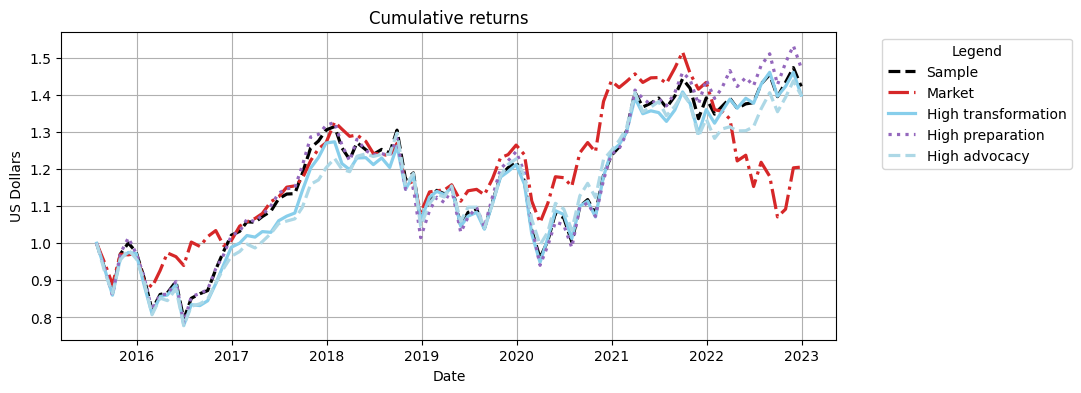

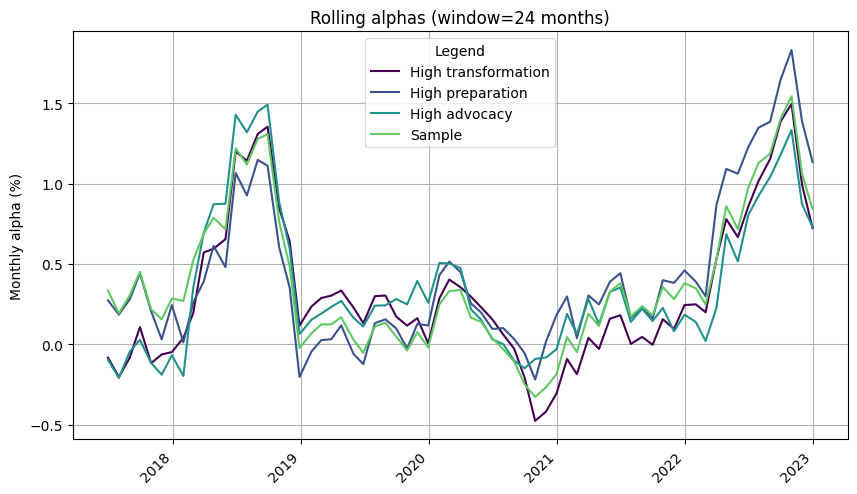

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Sample,-3.43%,1.98%,2.23%,2.23%,16.59%,9.01%,42.29%,42.29%
Market,0.17%,12.54%,-15.93%,-15.93%,-4.69%,-5.15%,20.54%,20.54%
High transformation,-4.20%,0.22%,2.88%,2.88%,15.47%,10.17%,39.95%,39.95%
High preparation,-3.89%,3.17%,2.26%,2.26%,18.11%,11.79%,47.30%,47.30%
High advocacy,-2.75%,3.23%,4.74%,4.74%,13.91%,16.21%,39.83%,39.83%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Sample,0.36,-11.35%,-26.95%,0.24,0.430
Market,0.25,-9.36%,-29.34%,,
High transformation,0.35,-11.62%,-25.52%,0.21,0.480
High preparation,0.37,-12.09%,-29.06%,0.27,0.410
High advocacy,0.36,-11.43%,-23.24%,0.21,0.510


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

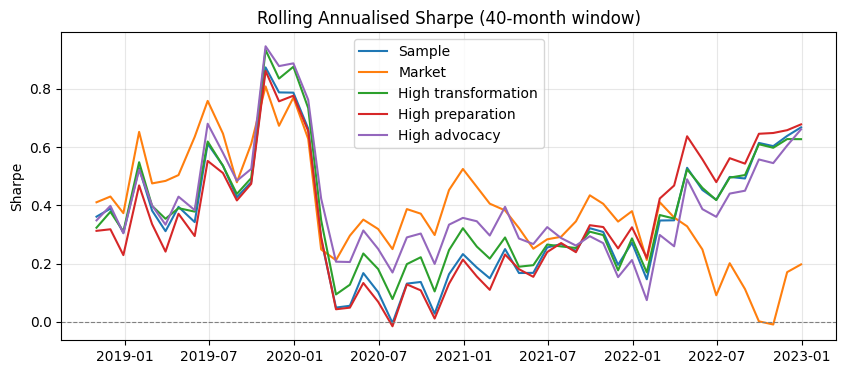

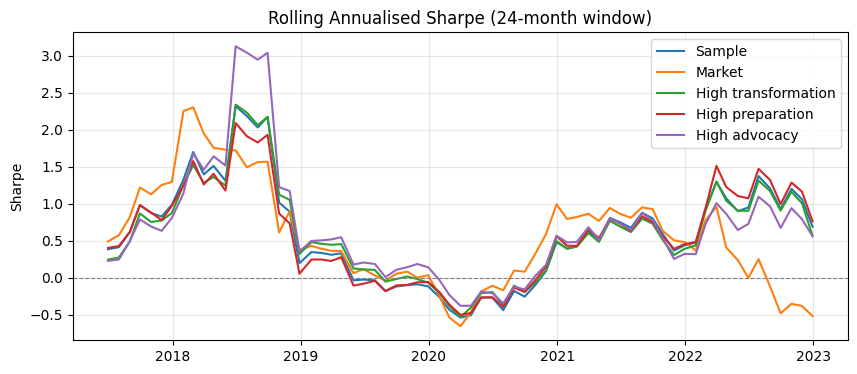

In [481]:
from functions.portfolio_metrics.Strategy_Perfomance import StrategyPerformance
from functions.portfolio_metrics.fama_french import plot_rolling_alpha_function



start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/{region_analysis}-strategy_cumulative_performance_split{no_simple_quantiles}--ff-{fama_factor_region}_{start_date}-{end_date}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/{region_analysis}-strategy_performance_metrics_split{no_simple_quantiles}--ff-{fama_factor_region}_{start_date}-{end_date}.csv")



sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=f"./output/img/{region_analysis}-cumulative_returns_split{no_simple_quantiles}--ff-{fama_factor_region}.png"
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title=f"Rolling alphas (window={window_size} months)",
    save_path=f"./output/img/{region_analysis}-rolling_alphas_split{no_simple_quantiles}-ff-{fama_factor_region}.png",
)

display(cumulative_table)
display(risk_table)


sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/{region_analysis}-strategy_rolling_sharpe_40m_split{no_simple_quantiles}-ff-{fama_factor_region}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/{region_analysis}-strategy_rolling_sharpe_24m_split{no_simple_quantiles}-ff-{fama_factor_region}.png")


# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

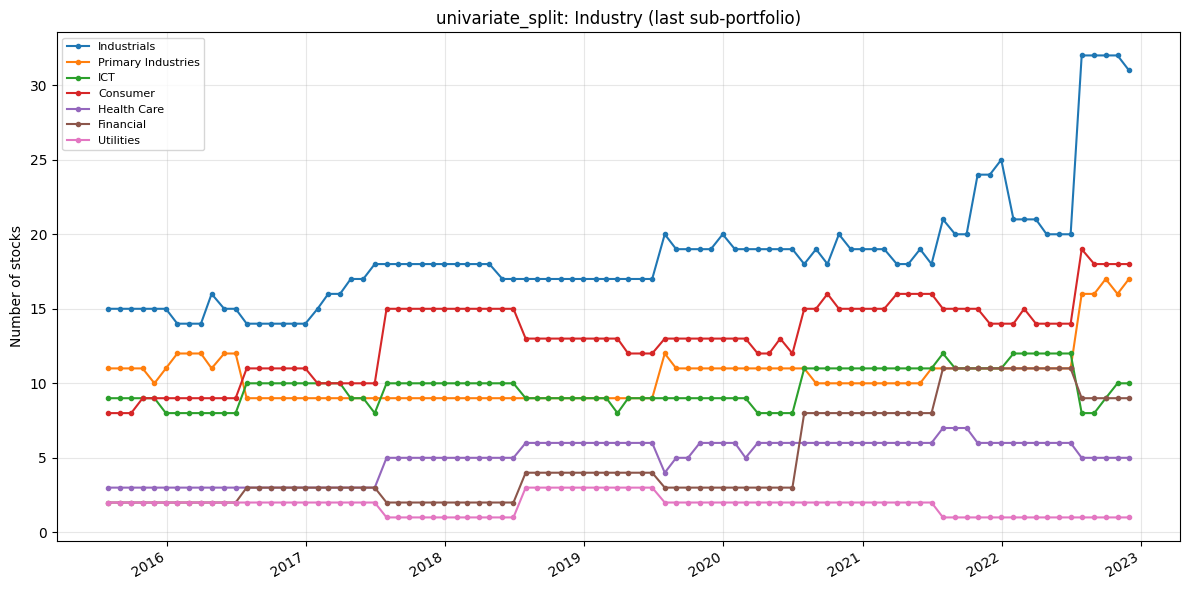

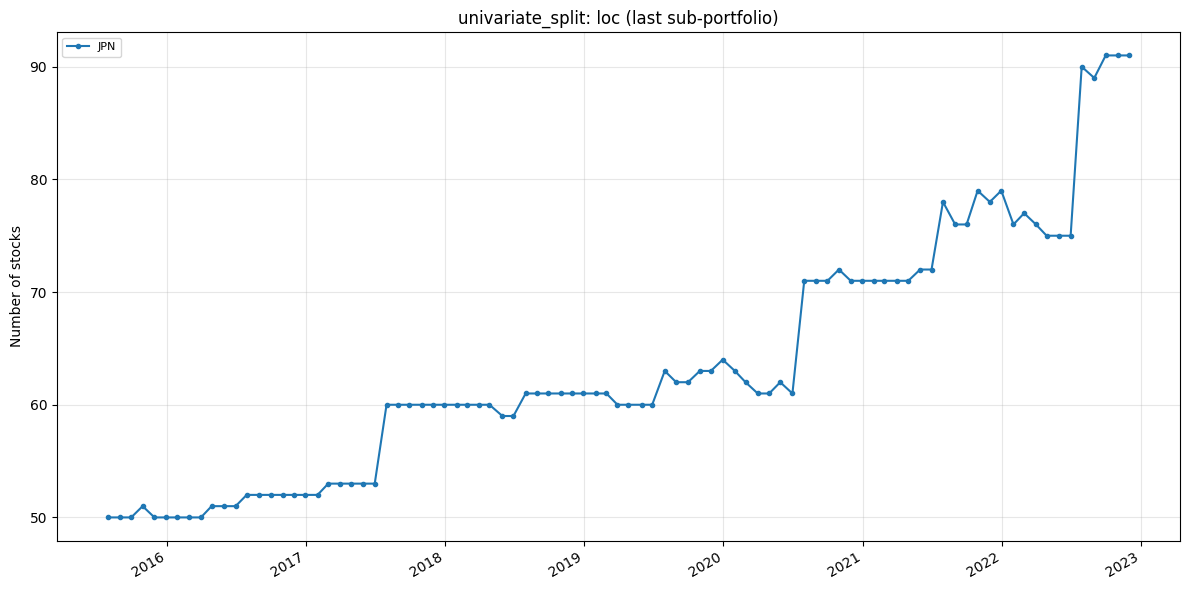

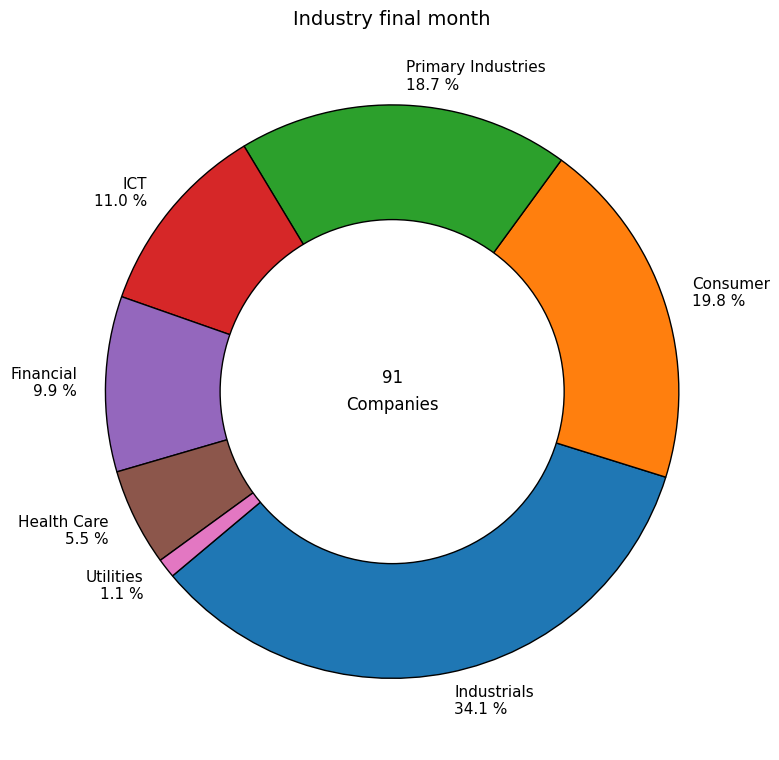

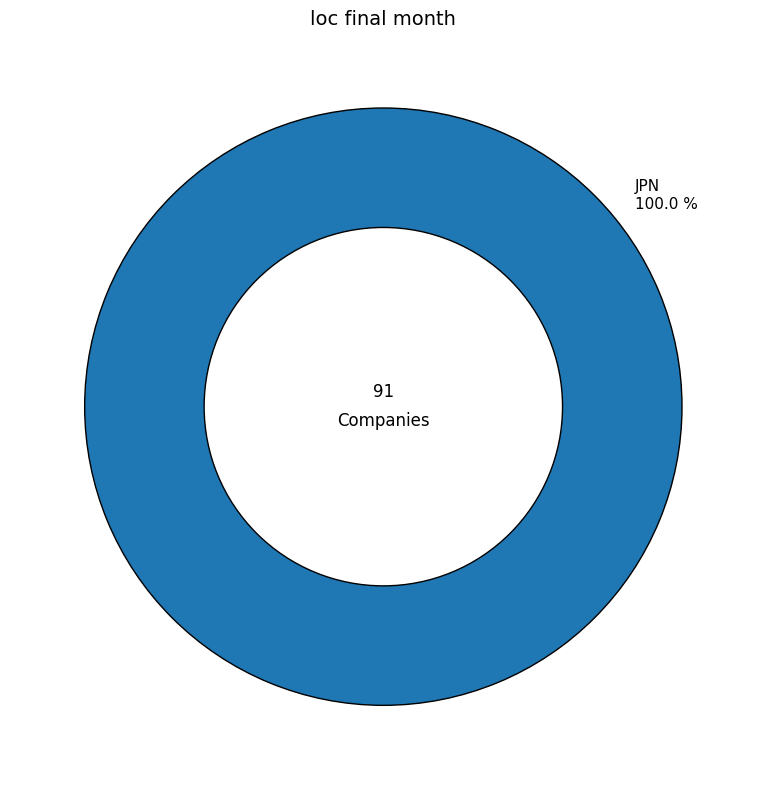

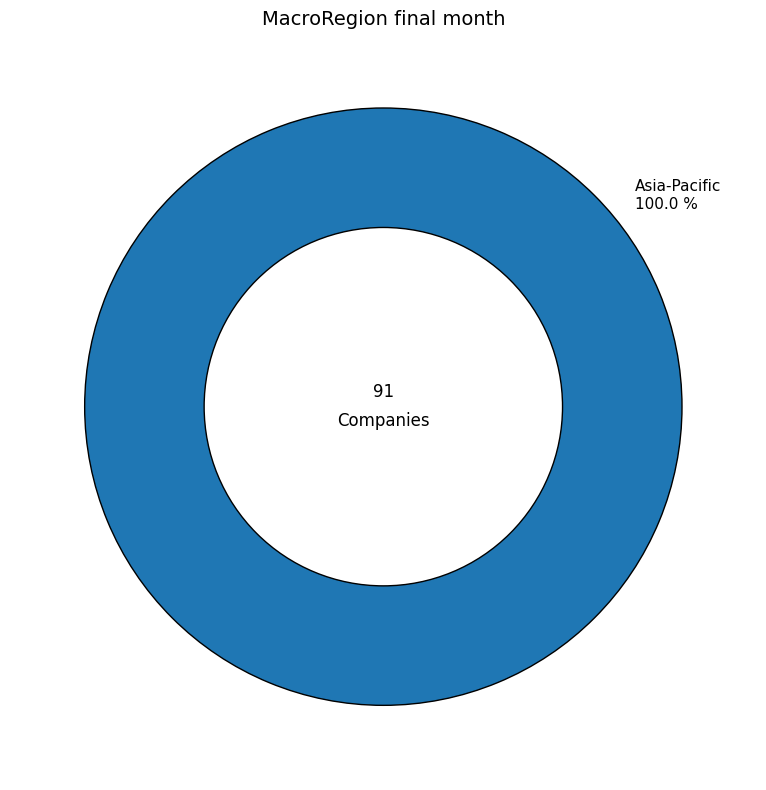

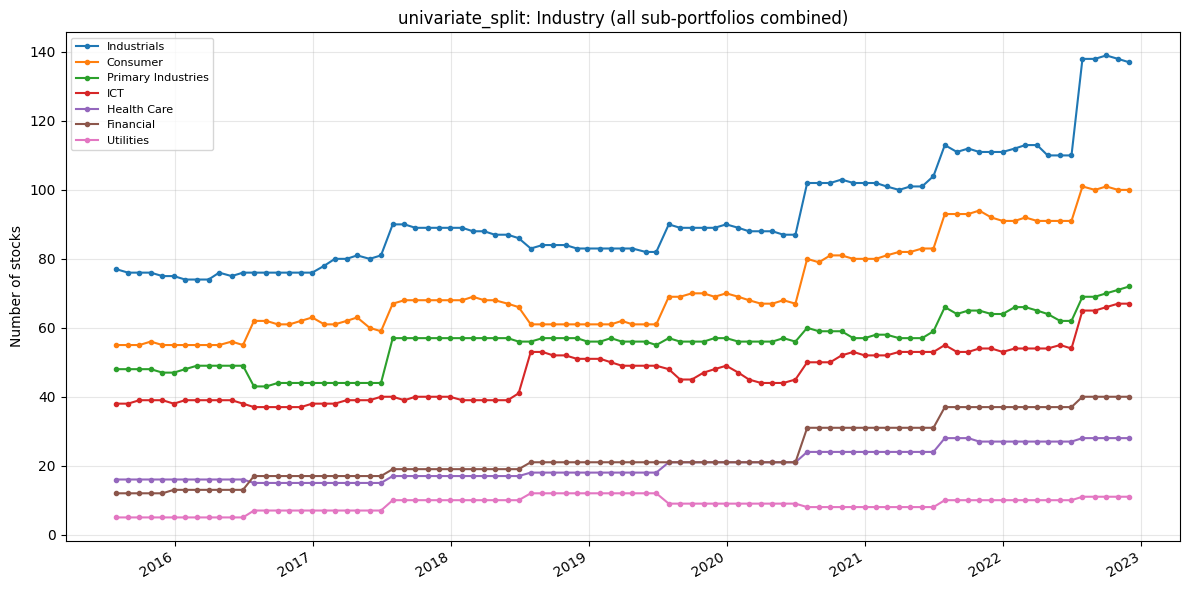

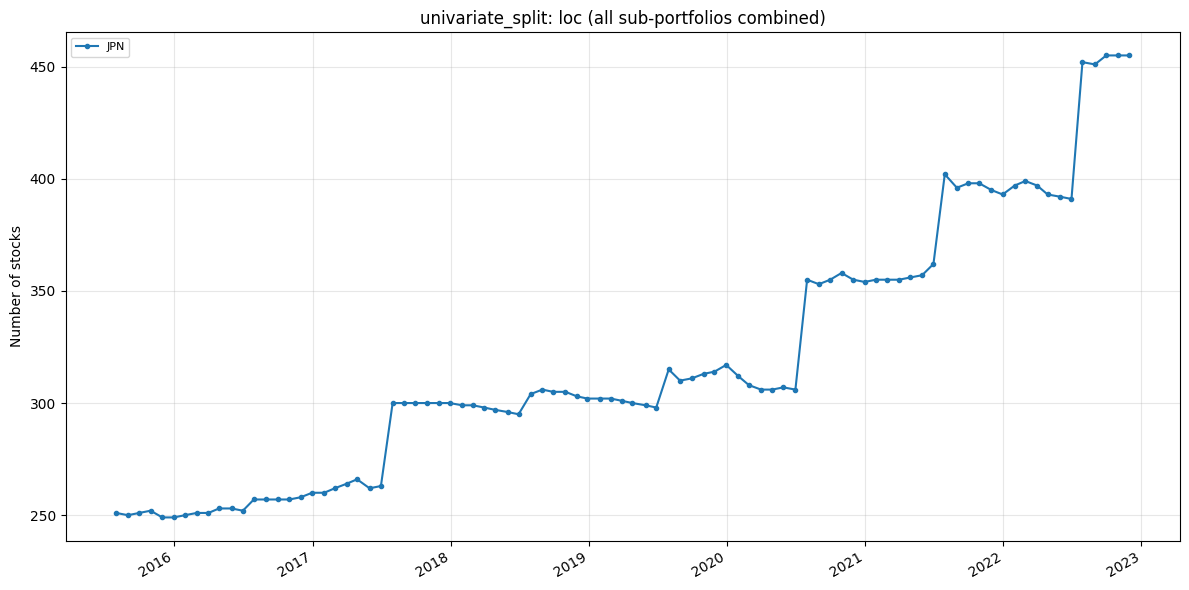

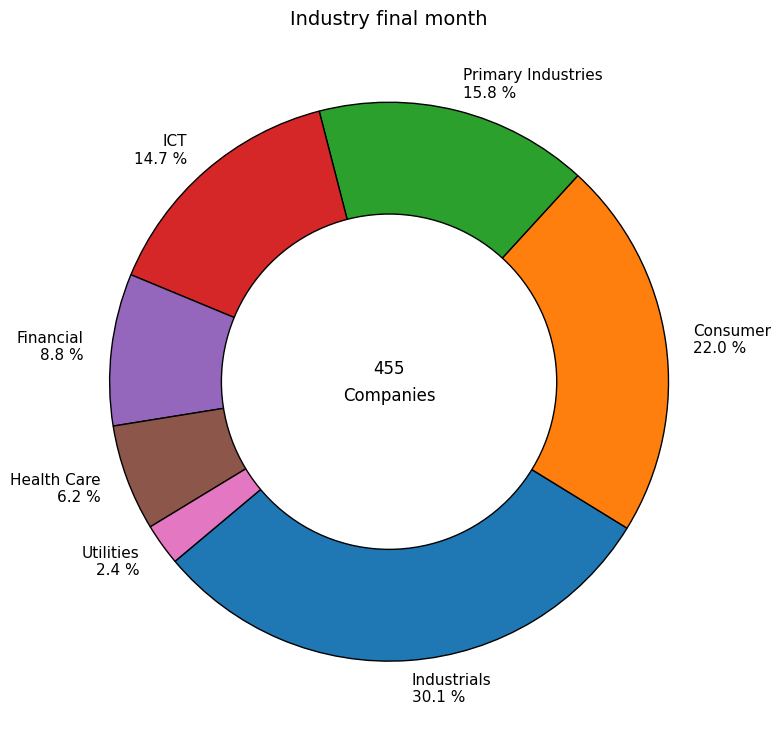

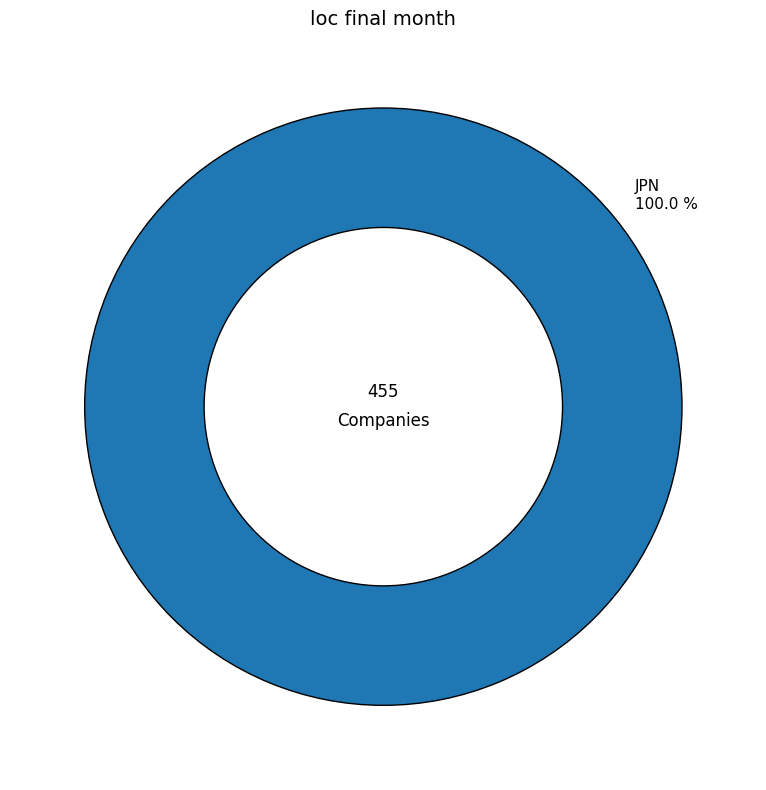

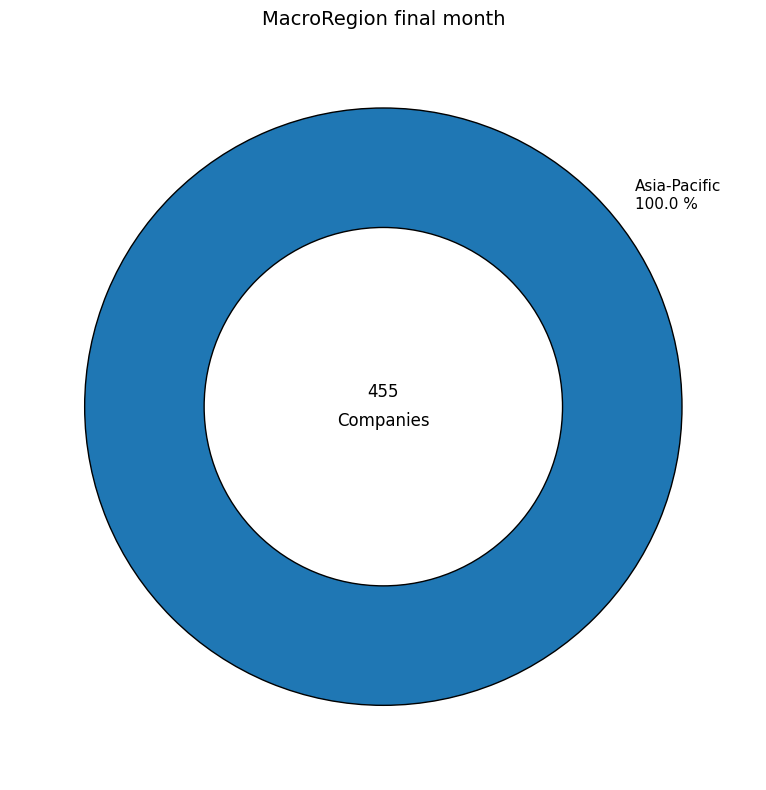

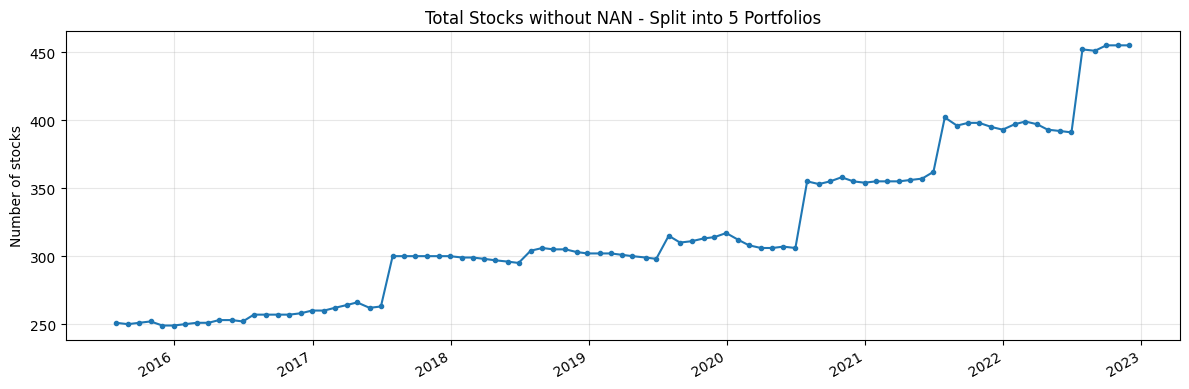

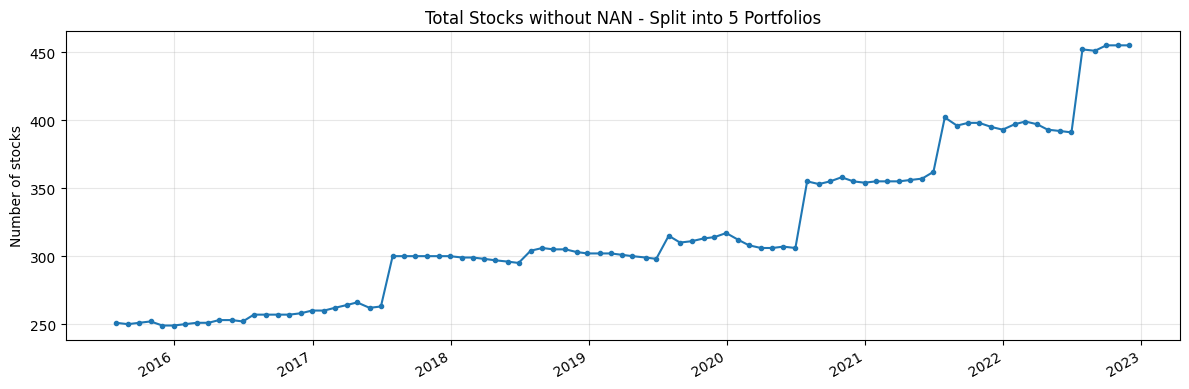

In [482]:
from IPython.display import display
from functions.portfolio_metrics.Portfolio_Constituents import PortfolioConstituents

# Portfolio constituents inspection is pinned to signal_2.
signal_2_simple_quantiles_constituents = signal_quantile_constituents["signal_2"]

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
